In [ ]:
# code to mount Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# change directory to where titanic.csv is located
%cd drive/MyDrive/'Colab Notebooks'

/content/drive/MyDrive/Colab Notebooks


In [ ]:
import numpy as np
import random
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier

In [ ]:
Iris = pd.read_csv('iris.csv')
Iris

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Virginica
146,6.3,2.5,5.0,1.9,Virginica
147,6.5,3.0,5.2,2.0,Virginica
148,6.2,3.4,5.4,2.3,Virginica


In [ ]:
Iris = Iris.sample(n = 10000, replace=True)
Iris

,sepal.length,sepal.width,petal.length,petal.width,variety
35,5.0,3.2,1.2,0.2,Setosa
113,5.7,2.5,5.0,2.0,Virginica
101,5.8,2.7,5.1,1.9,Virginica
45,4.8,3.0,1.4,0.3,Setosa
45,4.8,3.0,1.4,0.3,Setosa
...,...,...,...,...,...
6,4.6,3.4,1.4,0.3,Setosa
48,5.3,3.7,1.5,0.2,Setosa
26,5.0,3.4,1.6,0.4,Setosa
13,4.3,3.0,1.1,0.1,Setosa


In [ ]:
# make y (dependent variable) as np.array
y = np.array(Iris["variety"])

# make x a dataframe subset with independent variables
X = Iris[["sepal.length", "sepal.width", "petal.length", "petal.width"]]

# Split dataset into training and testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, train_size=0.7, random_state=42)

In [ ]:
#Builing my first forest with 100 trees and bagging as ensembly method

bagging_MyTree = BaggingClassifier(n_estimators=100,
                                max_features=3, random_state=42)

# Train the model
bagging_MyTree.fit(X_train, y_train)

# Model predictions
y_pred_bag = bagging_MyTree.predict(X_test)

# Calculate accuracy and confusion matrix of Bagging
accuracy = metrics.accuracy_score(y_test, y_pred_bag)

# Calculate confusion matrix
conf_matrix = metrics.confusion_matrix(y_test, y_pred_bag)

# Print accuracy, and confusion matrix
print("\nAccuracy:", accuracy)
print("\nConfusion Matrix:\n", conf_matrix)


Accuracy: 1.0

Confusion Matrix:
 [[1023    0    0]
 [   0  996    0]
 [   0    0  981]]


In [ ]:
from sklearn.tree import plot_tree, export_text
import matplotlib.pyplot as plt

In [ ]:
# Decision tree with pruned to level 4 with gini index
from sklearn.tree import DecisionTreeClassifier

# Create a Decision Tree Classifier using Gini index
MyTree = DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=42)

# Train the model
MyTree.fit(X_train, y_train)

# Predict the responses for test dataset
y_pred_dt = MyTree.predict(X_test)

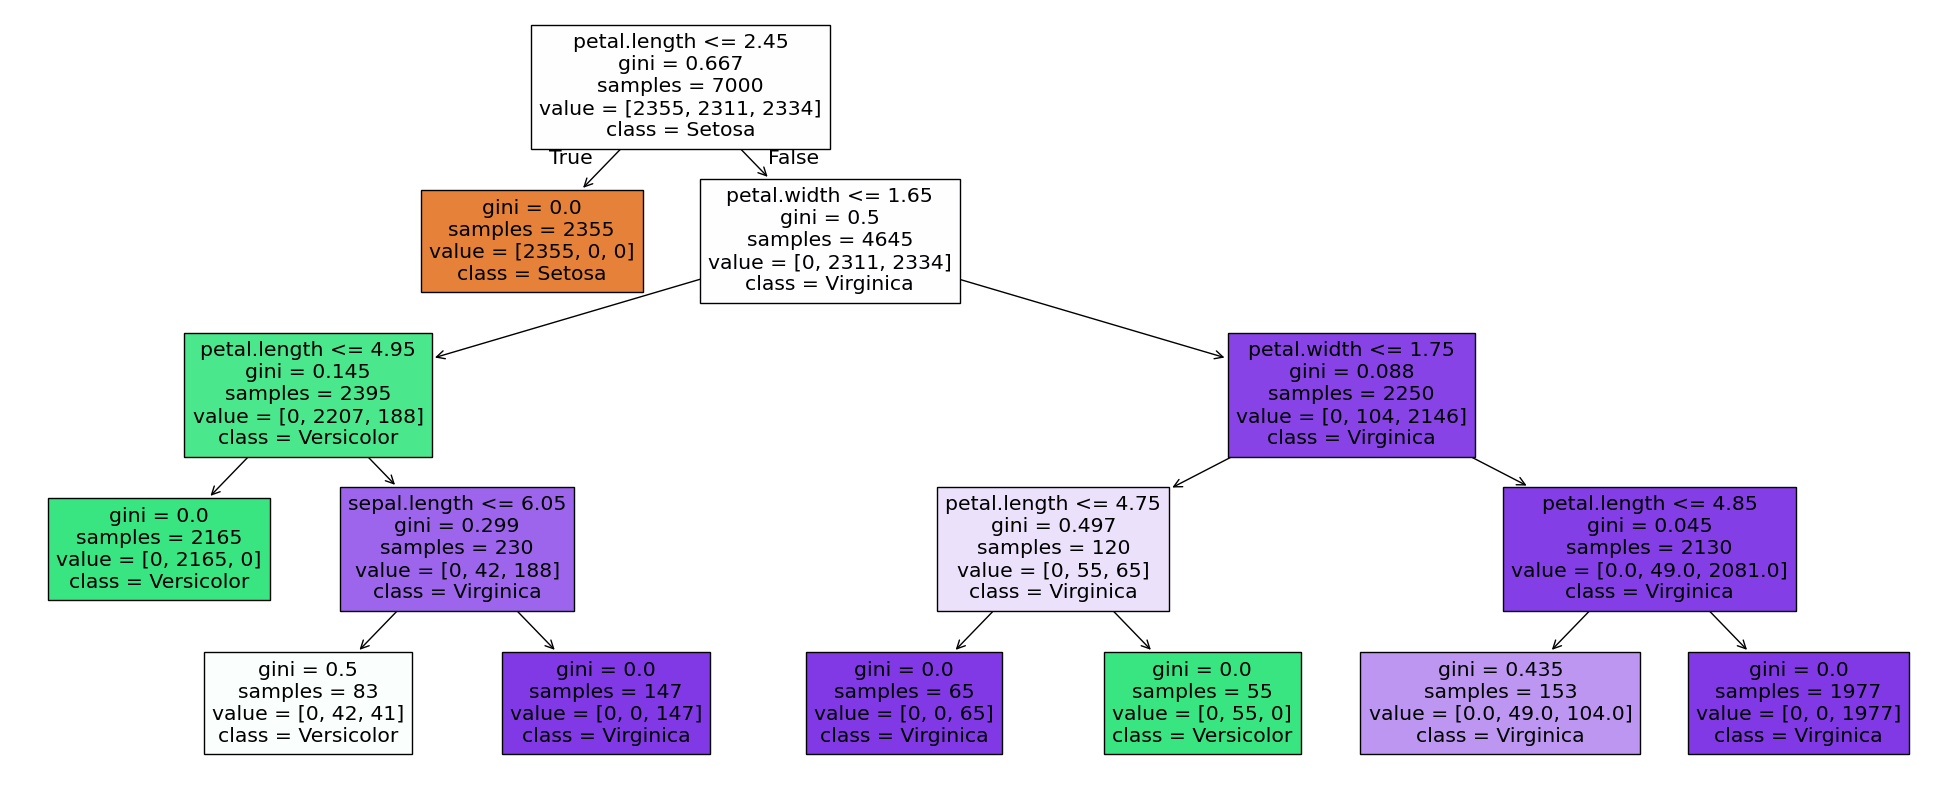

In [ ]:
# plot the tree
plt.figure(figsize = (25, 10))
plot_tree(MyTree,
    feature_names = list( X_train.columns),
    class_names = MyTree.classes_.astype(str).tolist(),
    filled = True)
plt.show()

In [ ]:
# Bagging

from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

# Create a Bagging Classifier with a Decision Tree
bagging_MyTree = BaggingClassifier(DecisionTreeClassifier(), n_estimators=100,
                                max_samples=1.0, random_state=42)

# Train the model
bagging_MyTree.fit(X_train, y_train)

# Model predictions
y_pred_bag = bagging_MyTree.predict(X_test)

In [ ]:
# Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

# Create a Random Forest Classifier
# n_estimators = number of trees to create
# criterion = ""gini", "entropy", "log_loss"} default="gini"
# max_features = {"sqrt", "log2", "None"} default = "sqrt"
MyRF = RandomForestClassifier(n_estimators=1000, random_state=42)

# Train the model
MyRF.fit(X_train, y_train)

# Model predictions
y_pred_rf = MyRF.predict(X_test)

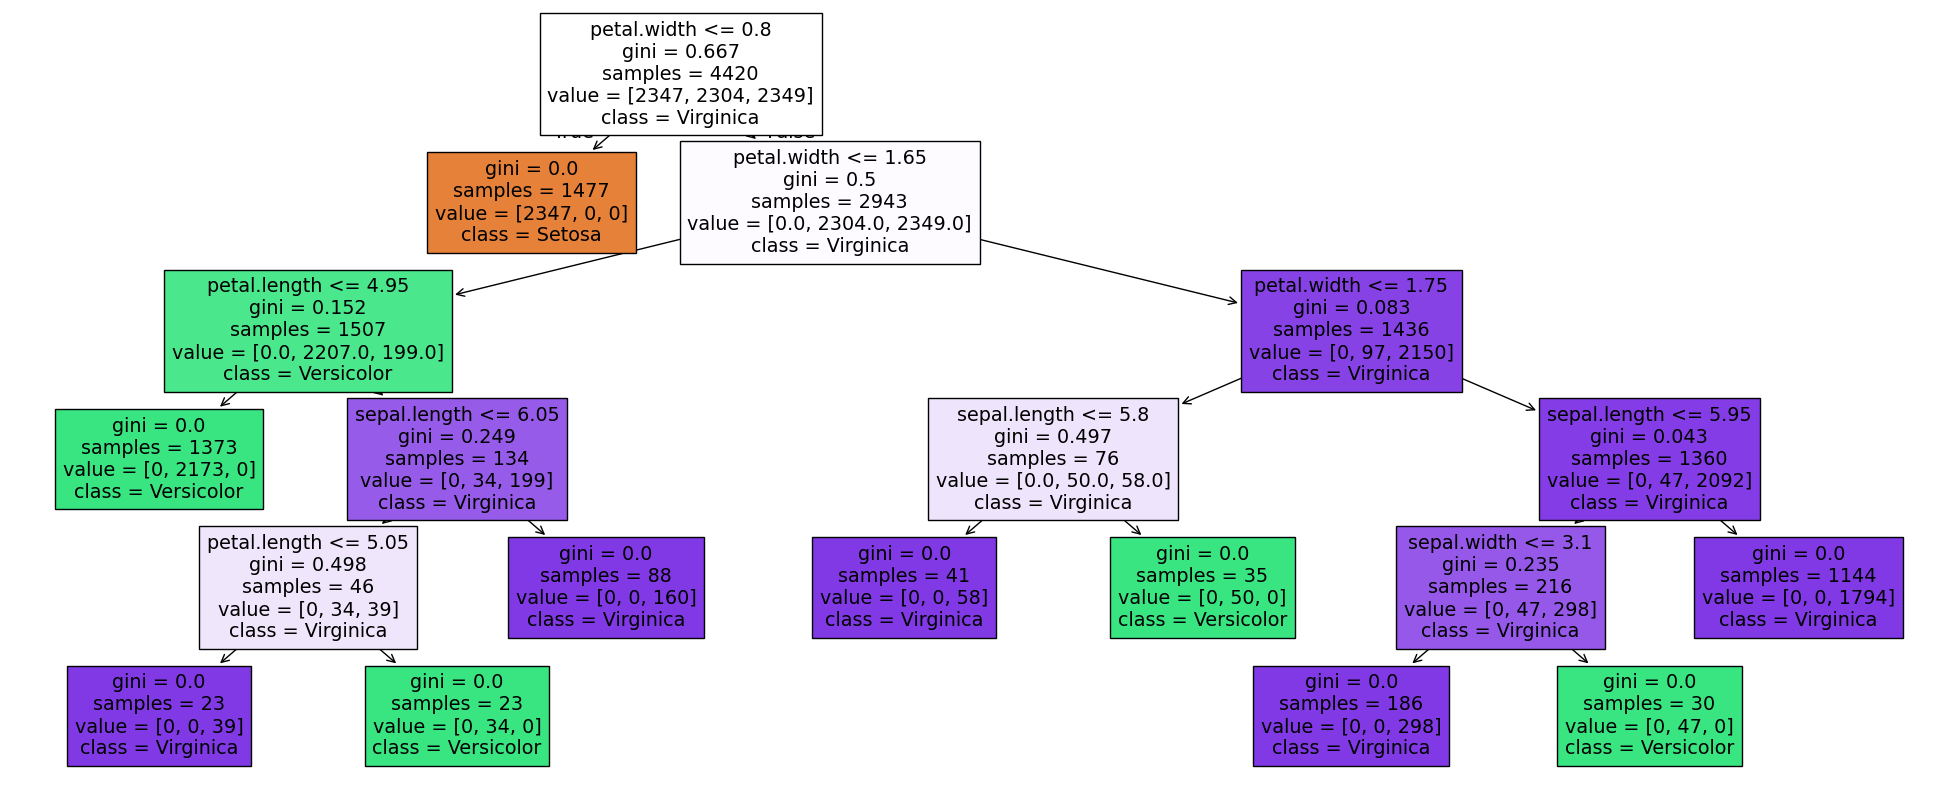

In [ ]:
# plot the tree
plt.figure(figsize = (25, 10))
# Select the first tree from the Random Forest for visualization
# A RandomForestClassifier is an ensemble, so you can't plot the entire forest at once.
# Instead, you can plot one of the individual decision trees within the forest.
plot_tree(MyRF.estimators_[0],
    feature_names = list( X_train.columns),
    class_names = MyRF.classes_.astype(str).tolist(),
    filled = True)
plt.show()